In [19]:
import sys,os
from os.path import basename
from glob import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
from astropy.stats import sigma_clip
from astropy.io import fits
import pandas as pd
from natsort import natsorted 
#import make_abs_calibration
#sys.path.append('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/astroskip/astroskip/image')
#sys.path.append('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/')
#from skipper_image import *
import warnings
warnings.filterwarnings("ignore")
#import peak_finding_algorithm 
#import fit_peaks
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as font_manager


In [17]:
# Photodiode calibration values from THORLABS
wave_photodiode, responsivity = np.loadtxt('./abs_calibration/thorlabs_photo_diode_calibration_full.txt',
                                           usecols=(0,1), 
                                            skiprows=(1), 
                                           unpack=True,delimiter=",")

#wave_photodiode=wave_photodiode
#responsivity=responsivity

def calibration_parameters(file):
    qe_calibration_data= np.loadtxt(file,usecols=(0,1,2,3,4),unpack=True)
    wave_cal= qe_calibration_data[0]
    sphere_power = (qe_calibration_data[1] + qe_calibration_data[2])/2
    cube_current=np.abs((qe_calibration_data[3] + qe_calibration_data[4]))/2
    
    return wave_cal, sphere_power, cube_current

def calculate_power(photo_current,responsivity):
    return photo_current/responsivity


In [10]:
sphere_readings = np.abs(np.load('./abs_calibration/ABS_cal_full_sphere.npy'))
sphere_readings = sphere_readings.reshape(71, int(len(sphere_readings)/71))
sphere_readings = np.median(sphere_readings, axis=1)

cube_readings =  np.abs(np.load('./abs_calibration/ABS_cal_full_cube.npy'))
cube_readings = cube_readings.reshape(71, int(len(cube_readings)/71))
cube_readings = np.mean(cube_readings,axis=1)
cube_readings = cube_readings*1.e-12
cube_power = calculate_power(cube_readings,responsivity)
area_ratio = (0.01)**2 / (1.5e-5)**2 
cube_power= cube_power/(area_ratio)

[3.35546875e-28 2.60231569e-28 2.42780650e-28 2.51564399e-28
 2.75440415e-28 3.10363636e-28 3.63963415e-28 4.27913603e-28
 4.98369932e-28 5.78132812e-28 6.66039244e-28 7.68811475e-28
 8.68192308e-28 9.59253641e-28 1.03066514e-27 1.10620087e-27
 1.18140625e-27 1.24962798e-27 1.32439163e-27 1.41927778e-27
 1.45394164e-27 1.48108750e-27 1.49013221e-27 1.50371528e-27
 1.51899481e-27 1.54480659e-27 1.56202003e-27 1.57382000e-27
 1.57650773e-27 1.57627500e-27 1.56087167e-27 1.53651408e-27
 1.50712329e-27 1.46937500e-27 1.42232955e-27 1.36474684e-27
 1.30433642e-27 1.24004276e-27 1.17234744e-27 1.10705357e-27
 1.04171165e-27 9.78457249e-28 9.23041590e-28 8.74141892e-28
 8.32826377e-28 7.96891419e-28 7.67543253e-28 7.42872432e-28
 7.21165110e-28 7.01035354e-28 6.82337229e-28 6.66598259e-28
 6.52345297e-28 6.41466227e-28 6.30468750e-28 6.24029605e-28
 6.21670792e-28 6.20466418e-28 6.19778428e-28 6.15805838e-28
 6.13221983e-28 6.07985372e-28 6.02802045e-28 5.98630240e-28
 5.94628603e-28 5.968298

sphere_readings2 = np.abs(np.load('./qe_calibration_07_10_2023/ABS_cal_full_sphere_07_10_2023_3.npy'))
sphere_readings2 = sphere_readings2.reshape(len(wave_photodiode), int(len(sphere_readings2)/len(wave_photodiode)))
sphere_readings2 = np.median(sphere_readings2, axis=1)

cube_readings2 =  np.loadtxt('./qe_calibration_07_10_2023/cube_photodiode_07_10_23_3.txt',unpack=True)
cube_readings2 = cube_readings2.reshape(len(wave_photodiode), int(len(cube_readings2)/len(wave_photodiode)))
cube_readings2 = np.mean(cube_readings2,axis=1)
cube_readings2 = cube_readings2*1.e-9
cube_power2 = calculate_power(cube_readings2,responsivity)
area_ratio = (0.01)**2 / (1.5e-5)**2 
cube_power2= cube_power2/(area_ratio)


In [12]:
sphere_readings3 = np.abs(np.load('./qe_calibration_07_11_2023/ABS_cal_full_sphere_07_11_2023_1.npy'))
sphere_readings3 = sphere_readings3.reshape(len(wave_photodiode), int(len(sphere_readings3)/len(wave_photodiode)))
sphere_readings3 = np.median(sphere_readings3, axis=1)

cube_readings3 =  np.loadtxt('./qe_calibration_07_11_2023/photo_diode_07_11_23_1.txt',unpack=True)
cube_readings3 = cube_readings3.reshape(len(wave_photodiode), int(len(cube_readings3)/len(wave_photodiode)))
cube_readings3 = np.mean(cube_readings3,axis=1)
cube_readings3 = cube_readings3*1.e-9
cube_power3 = calculate_power(cube_readings3,responsivity)
area_ratio = (0.01)**2 / (1.5e-5)**2 
cube_power3= cube_power3/(area_ratio)

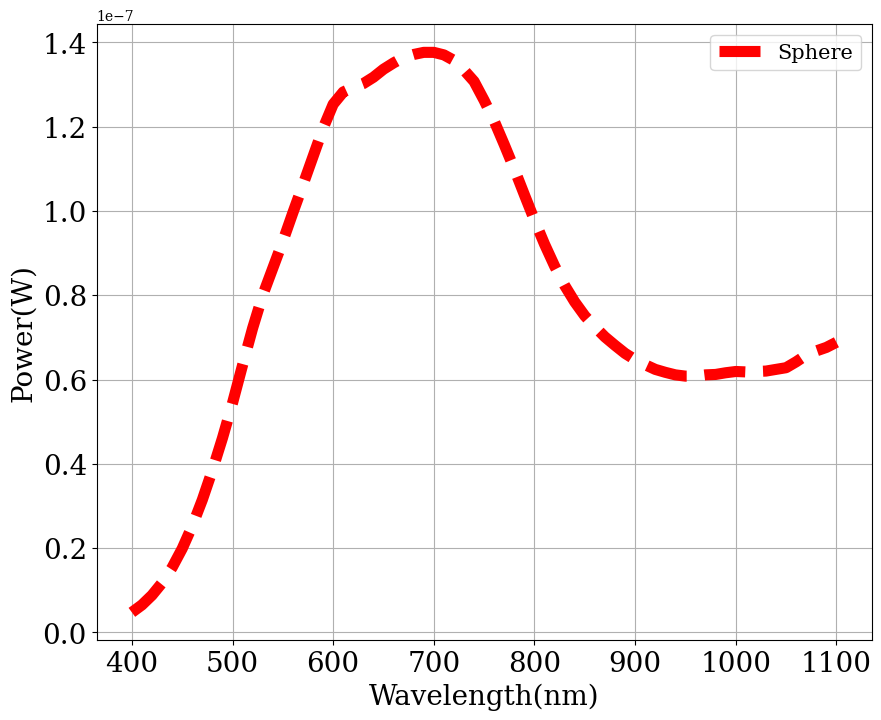

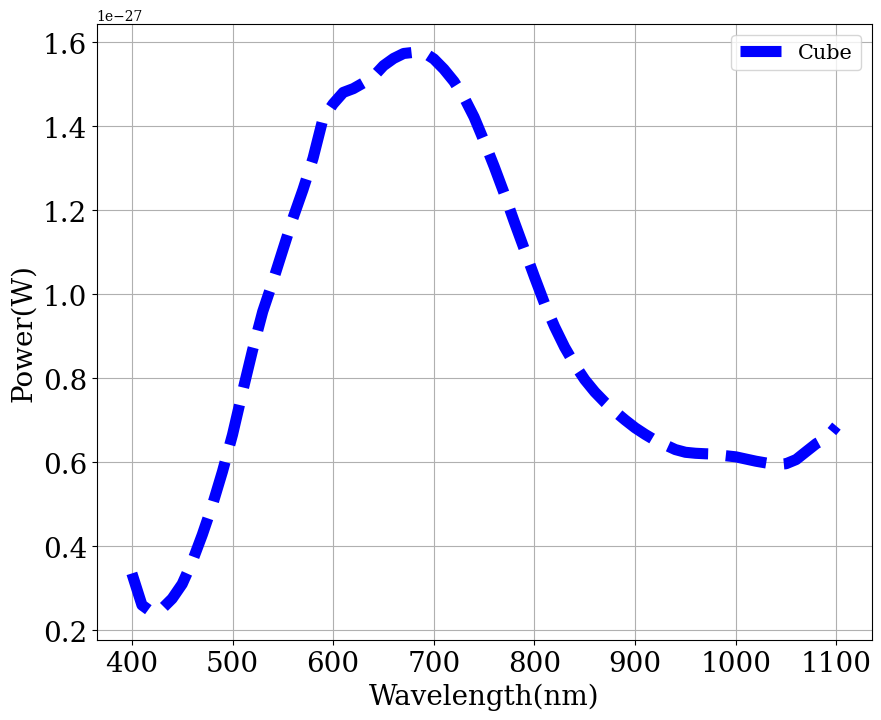

In [11]:
# Plot Cube and Sphere Power
fig, ax = plt.subplots(figsize=(10, 8))

plt.plot(wave_photodiode,sphere_readings, '--r',label='Sphere',linewidth=8)
#plt.plot(wave_photodiode,sphere_readings2, '--g',label='Sphere 2',linewidth=8)
#plt.plot(wave_photodiode,sphere_readings3, '--',color='purple',label='Sphere 3',linewidth=8)


plt.ylabel("Power(W)", fontsize=20)
plt.xlabel("Wavelength(nm)",fontsize=20)
plt.legend(loc='best', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.grid()
plt.show()


fig, ax = plt.subplots(figsize=(10, 8))

plt.plot(wave_photodiode,cube_power, '--b',label='Cube',linewidth=8)
#plt.plot(wave_photodiode,cube_power2, '--g',label='Cube 2',linewidth=8)
#plt.plot(wave_photodiode,cube_power3, '--',color='cyan',label='Cube e',linewidth=8)



plt.ylabel("Power(W)", fontsize=20)
plt.xlabel("Wavelength(nm)",fontsize=20)
plt.legend(loc='best', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.grid()
plt.show()


In [13]:
def make_calibration(wavelengths,sphere_power,cube_power):
    calibration = cube_power/sphere_power
    data = np.column_stack([wavelengths, calibration])
    np.savetxt=("./Absolute_calibration_for_QE.txt",data)
    
    return calibration

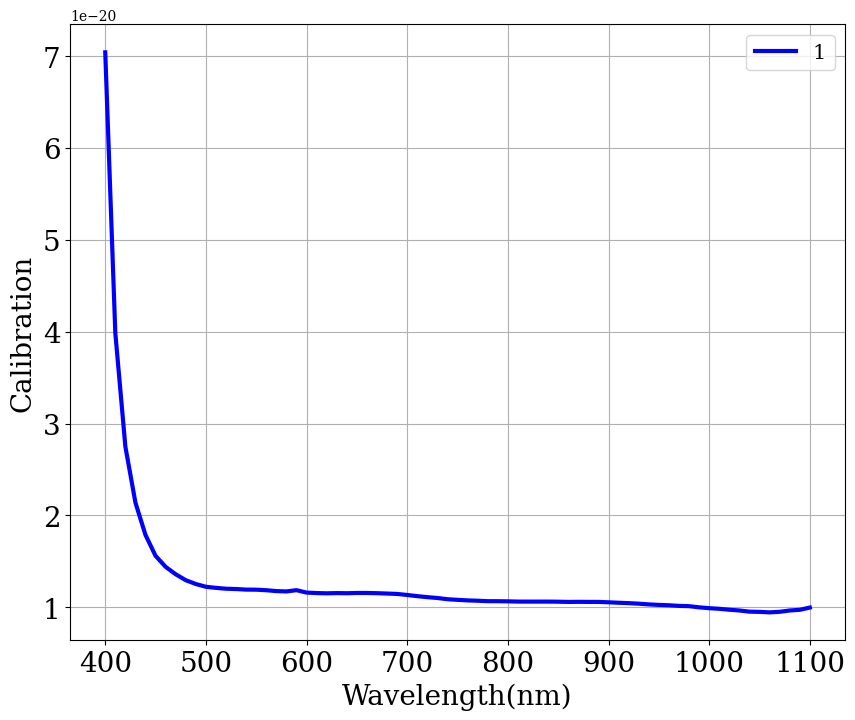

In [16]:
calibration =  make_calibration(wave_photodiode,sphere_readings,cube_power)

#calibration_og =make_abs_calibration.get_calibration()

#calibration2 =  make_calibration(wave_photodiode,sphere_readings2,cube_power2)
#calibration3 =  make_calibration(wave_photodiode,sphere_readings3,cube_power3)

#combined = np.array([calibration2,calibration3])

#print(np.std(combined,axis=0))

fig, ax = plt.subplots(figsize=(10, 8))

plt.plot(wave_photodiode,calibration, 'b',label='1',linewidth=3)
#plt.plot(wave_photodiode,calibration2, 'g',label='1',linewidth=3)

#plt.plot(wave_photodiode,calibration_og[::2], 'r',label='OG',linewidth=3)

#plt.plot(wave_photodiode,calibration3, '--',color='orange',label='2',linewidth=3)



plt.ylabel("Calibration", fontsize=20)
plt.xlabel("Wavelength(nm)",fontsize=20)
plt.legend(loc='best', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=20)
#plt.xlim(500,1200)
#plt.ylim(0,1.6e-8)
plt.grid()
plt.show()


#(np.abs(calibration2 - calibration3) / ((calibration3 + calibration3) / 2)) * 100

In [15]:
qe_error = np.array([5.01064768,  3.61419069,  5.88335073,  6.12260305,  5.55555556,
        5.31079284,  4.60684206,  4.50933188,  3.75818282,  3.64411962,
        3.04314351,  2.92355098,  2.88575354,  2.56293146,  2.52097059,
        2.12402247,  2.11670624, 2.59069473,  1.78045994,  2.17980978,
        1.94928588,  1.97103749,  1.8002115 ,  1.47005277,  2.12794613,
        2.01370483,  2.46178457,  0.75568063,  2.31862306,  3.02821896,
        2.54505311,  3.75335121,  5.18991977,  5.57086062,  5.19527777,
        5.09337861])/100

In [16]:
# AstroSkipper #22

qe_files = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/AstroSkipper_22/qe_20230606_00/*.fits')))
qe_files_fz = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/AstroSkipper_22/qe_20230606_00/*.fz')))
bckg = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/AstroSkipper_22/20230602_Background/*.fz')))

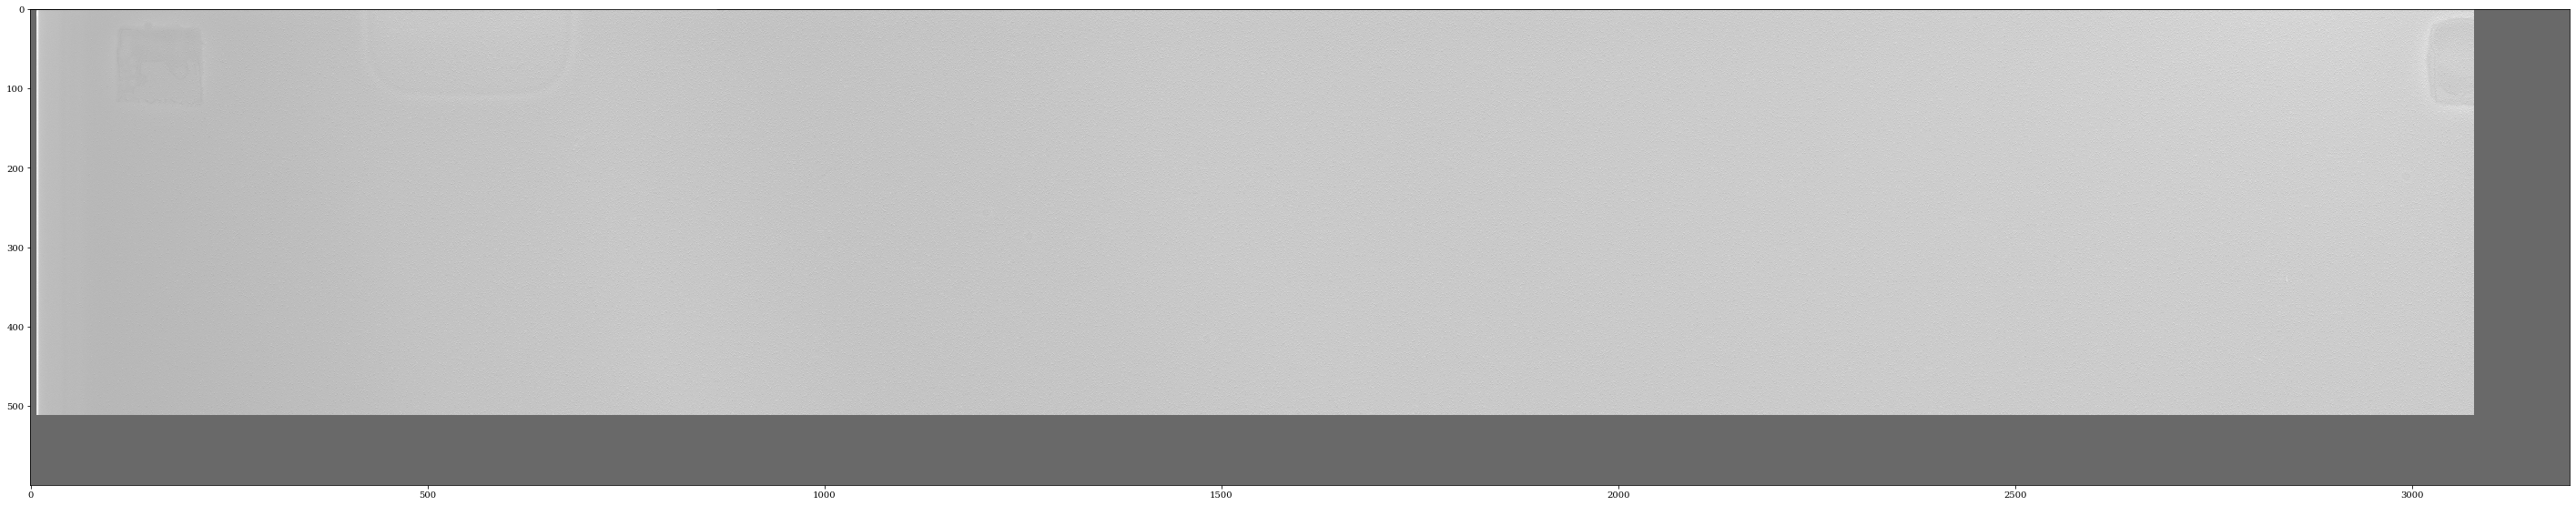

In [6]:
# AstroSkipper #22
img = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/AstroSkipper_22/qe_20230606_00/proc_qe_lta_t2.0_w680_n1_i0_233.fits')))
data_img = fits.open(img[0])
data_img = data_img[0].data

fig, ax = plt.subplots(figsize=(50, 50))
plt.imshow(data_img,cmap='gray')
plt.show()


In [ ]:
# MBE Detector
qe_files_mbe = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/MBE_detector/qe_20230719_00/*.fits')))
qe_files_fz_mbe = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/MBE_detector/qe_20230719_00/*.fz')))
bckg_mbe = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/MBE_detector/*.fz')))

In [ ]:
# MBE Detector
img_mbe = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/MBE_detector/qe_20230714_00/proc_qe_lta_t2.0_w680_n1_i0_25.fits')))
data_img_mbe = fits.open(img_mbe[0])
data_img_mbe = data_img_mbe[0].data

fig, ax = plt.subplots(figsize=(50, 50))
plt.imshow(data_img_mbe,cmap='gray')
plt.show()

In [7]:
# AstroSkipper 20 
qe_files_astro20 = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/AstroSkipper_20/qe_20230727_00/*.fits')))
qe_files_fz_astro20 = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/AstroSkipper_20/qe_20230727_00/*.fz')))
#bckg_astro20 = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/AstroSkipper_20/20230418_Background/*.fz')))
bckg_astro20 = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_data/AstroSkipper_20/*.fz')))


In [8]:
def get_gain(image,plot=True,disp=True):
    hdus=4
    img = SkipperImage(image)
    img_os = img.getImages()
    gain=dict()
    gain_arr=list()
    for i in range(hdus):
        clipped_img_os = sigma_clip(img_os[i].flatten(),sigma=2.5)
        _, _, k =peak_finding_algorithm.get_peaks(clipped_img_os, plot=plot)
        
        gain_arr.append(k)
    
    gain_arr=np.array(gain_arr)
    gain_arr=np.nan_to_num(gain_arr)
    m = np.median(gain_arr[gain_arr > 0])
    gain_arr[gain_arr == 0] = m
    
    for i in range(hdus):
        gain.update({i:[gain_arr[i]]})

    if disp:
        df = pd.DataFrame(data=gain)
        df.style.set_table_attributes('style="font-size: 17px"')
        
        title="Gain Measurments (ADUs/e-)"
        display(Markdown('<strong>{}'.format(title)))
        display(df)
    
    return np.array(gain_arr)

#get_gain(bckg_astro20[0])


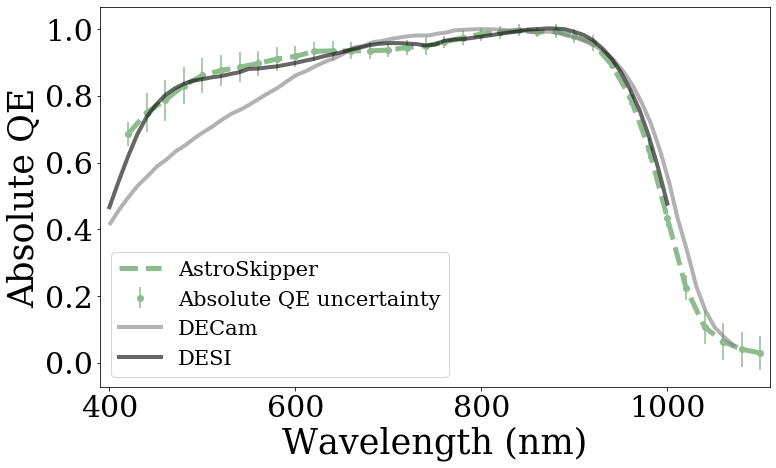

[420.0, 440.0, 460.0, 480.0, 500.0, 520.0, 540.0, 560.0, 580.0, 600.0, 620.0, 640.0, 660.0, 680.0, 700.0, 720.0, 740.0, 760.0, 780.0, 800.0, 820.0, 840.0, 860.0, 880.0, 900.0, 920.0, 940.0, 960.0, 980.0, 1000.0, 1020.0, 1040.0, 1060.0, 1080.0, 1100.0]
[0.68513775 0.75022401 0.78734541 0.83117725 0.86149584 0.87643427
 0.88617632 0.89765229 0.91066856 0.91872726 0.93389041 0.93515971
 0.9352455  0.93526966 0.93765606 0.94520705 0.94978819 0.96162882
 0.97467413 0.98565014 0.99129811 0.9977037  0.99210105 0.99372865
 0.97940959 0.95810742 0.89362245 0.79705207 0.6425912  0.43411189
 0.22491217 0.10732945 0.06401762 0.04092582 0.03003962]


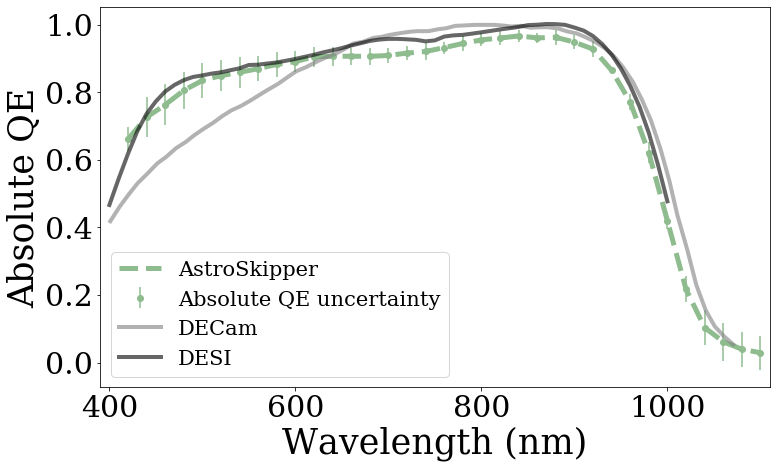

[420.0, 440.0, 460.0, 480.0, 500.0, 520.0, 540.0, 560.0, 580.0, 600.0, 620.0, 640.0, 660.0, 680.0, 700.0, 720.0, 740.0, 760.0, 780.0, 800.0, 820.0, 840.0, 860.0, 880.0, 900.0, 920.0, 940.0, 960.0, 980.0, 1000.0, 1020.0, 1040.0, 1060.0, 1080.0, 1100.0]
[0.6615938  0.72650889 0.76328651 0.80583127 0.83530155 0.84959197
 0.85942182 0.87032707 0.88289634 0.89109827 0.90563583 0.90698798
 0.90703812 0.90676107 0.90944294 0.91636879 0.92116129 0.93257678
 0.94486212 0.95553663 0.96096762 0.96708218 0.96157658 0.96301167
 0.94897208 0.92824376 0.86574196 0.77150932 0.62168514 0.41981928
 0.21731993 0.103645   0.06166894 0.03948492 0.0289835 ]


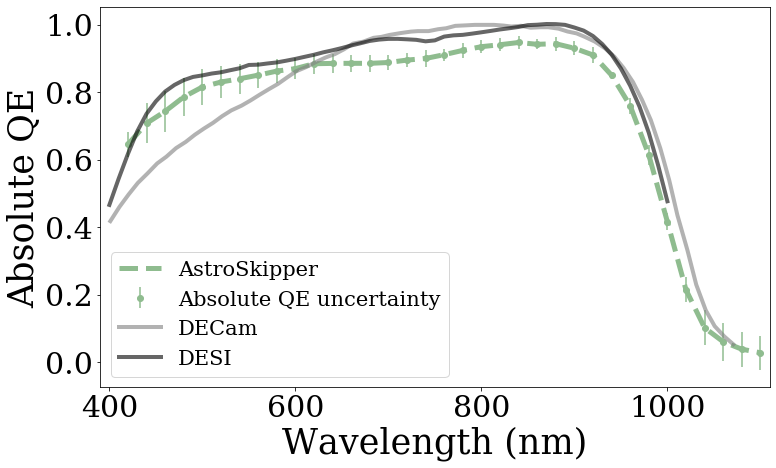

[420.0, 440.0, 460.0, 480.0, 500.0, 520.0, 540.0, 560.0, 580.0, 600.0, 620.0, 640.0, 660.0, 680.0, 700.0, 720.0, 740.0, 760.0, 780.0, 800.0, 820.0, 840.0, 860.0, 880.0, 900.0, 920.0, 940.0, 960.0, 980.0, 1000.0, 1020.0, 1040.0, 1060.0, 1080.0, 1100.0]
[0.64592104 0.70847664 0.74392174 0.78649655 0.81597209 0.83063377
 0.84025901 0.85103057 0.86299676 0.87038731 0.88488659 0.88583136
 0.88607749 0.88600279 0.88852054 0.8956589  0.90041595 0.91172265
 0.92437434 0.9354315  0.94114133 0.94778813 0.94242849 0.94413394
 0.93074103 0.91077399 0.85082986 0.76046761 0.61477149 0.41677571
 0.21512317 0.10249655 0.06118008 0.03905024 0.02858031]


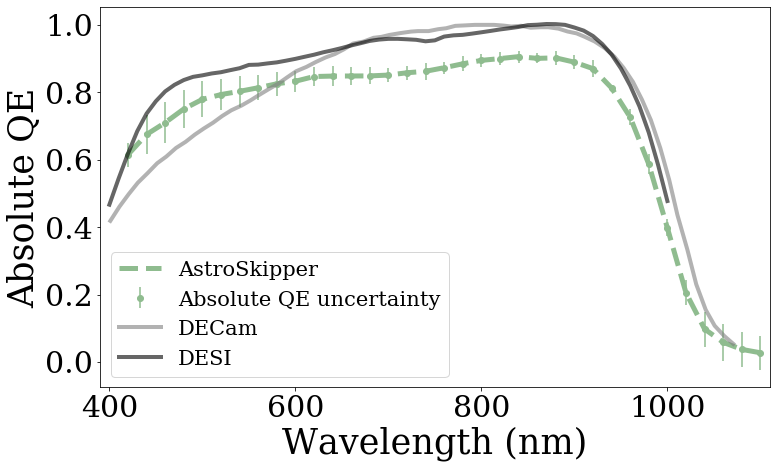

[420.0, 440.0, 460.0, 480.0, 500.0, 520.0, 540.0, 560.0, 580.0, 600.0, 620.0, 640.0, 660.0, 680.0, 700.0, 720.0, 740.0, 760.0, 780.0, 800.0, 820.0, 840.0, 860.0, 880.0, 900.0, 920.0, 940.0, 960.0, 980.0, 1000.0, 1020.0, 1040.0, 1060.0, 1080.0, 1100.0]
[0.61485859 0.67483527 0.70989548 0.75048792 0.7789991  0.79324341
 0.80285519 0.81340991 0.82519636 0.83270904 0.84668322 0.84805615
 0.84835135 0.84858131 0.85104244 0.85790296 0.86230454 0.87287258
 0.88451932 0.89465389 0.89996186 0.90578961 0.90061787 0.90210249
 0.88937159 0.87013195 0.81279724 0.72608262 0.58666671 0.39765994
 0.20512861 0.09754194 0.0581524  0.03715458 0.02720372]


In [23]:
# Absolute QE Calculation

def calculate_abs_qe(proc_qe_files,raw_qe_files,bckg,exp_time=4.3):
    hdus=4
    gain=get_gain(bckg,plot=False,disp=False)
    h=6.625e-34
    c=2.998e8
    OSS=3079
    # This corresponds roughly to the location of the photodiode on the AstroSkipper package 
    row_min=50
    row_max=500
    col_min=3050
    
    """Get QE data from a file list.

    Parameters:
    -----------
    files : file list
    gain  : detector gain [ADU/e-]
    
    Returns
    -------
    data : summary data from images
    """
    abs_QE = np.zeros(shape=(hdus,len(proc_qe_files)))
    waves=list()
    power=list()
    
    for fz in raw_qe_files:
        hdr=fits.open(fz)[0].header
        waves.append(hdr['WAVE'])
        power.append(hdr['POWER'])
    
    power =np.array(power)*(calibration2)#+calibration3)/2.#make_abs_calibration.get_calibration()[::2]
    #plt.plot(waves,power)
  
    for hdu in range(hdus):
        for i,f in enumerate(proc_qe_files):
            img=fits.open(f)
            os=sigma_clip(img[hdu].data[:,OSS:].flatten(),maxiters=None)
            act=sigma_clip(img[hdu].data[row_min:row_max,col_min:OSS].flatten(),maxiters=None)
            
            # Compute absolute QE
            
            mean_OS = np.mean(os)
            mean_ACT = np.mean(act)
            mean = mean_ACT-mean_OS
            
            # Convert from ADUs to elelctrons 
            mean_electron=mean/gain[hdu]
            abs_qe = mean_electron * ((h*c)/(power[i]*exp_time*(waves[i])/(1e9)))
            abs_QE[hdu][i]=abs_qe
    
    h,q,w=np.loadtxt('qe.txt',usecols=(0,1,2),unpack=True)
    #r = np.loadtxt('silicon_reflectivity.txt',usecols=(1),unpack=True)
    #print(r)
    flaugher = pd.read_csv('decam_qe_flaugher.csv',comment='#')
    font = FontProperties(size= 35)
    font.set_style('normal')

    QE_astro = np.load("./QE_Astro_22.npy")
    for hdu in range(hdus):

        fig, ax = plt.subplots(figsize=(12, 7))
        #plt.plot(waves[1:],abs_QE[hdu][1:]/(1-r),'--r',alpha=0.8,linewidth=5,
                 #label="g11-wf-215974-10",
                 #zorder=1)
        plt.plot(waves[1:],abs_QE[hdu][1:],linestyle='--',alpha=1,linewidth=5,
                 label="AstroSkipper",
                 zorder=1,color='darkseagreen')
        plt.errorbar(waves[1:],abs_QE[hdu][1:], yerr=qe_error[1:], zorder=2, fmt='o',color='darkseagreen',
                    label="Absolute QE uncertainty")
        plt.plot(flaugher['wave'],flaugher['qe']/flaugher['qe'].max(),
                ls='-',lw=4,color='gray',
                 label='DECam',zorder=3,alpha=0.6)
        plt.plot(w[0:61],q[0:61],lw=4,color='black',label='DESI',zorder=4,alpha=0.6)
        #plt.plot(waves[1:],QE_astro[1][1:],'--b',linewidth=5,label='AstroSkipper')
        plt.xlim(390,1110)
        #plt.grid()
        ax.set_xlabel('Wavelength (nm)',fontproperties=font)
        ax.set_ylabel('Absolute QE',fontproperties=font)
        ax.tick_params(axis='both', which='major', labelsize=30)
        handles,labels = ax.get_legend_handles_labels()
        handles = [handles[0], handles[3], handles[1],handles[2]]
        labels = [labels[0], labels[3], labels[1],labels[2]]
        plt.legend(handles,labels,fontsize=21)
        #plt.ylim(0,1.3)
        plt.savefig("ABS_QE_HDU_{}.pdf".format(hdu), bbox_inches='tight')
        plt.show()
        
        print(waves[1:])
        print(abs_QE[hdu][1:])
        
        #stack = np.column_stack([waves[1:],abs_QE[hdu][1:]])
        
        data_qe = {'Wavelength': waves[1:] , 'QE': abs_QE[hdu][1:]}
        df = pd.DataFrame(data_qe)
        df.to_csv('ABS_QE_HDU_{}.csv'.format(hdu), index=False)
        
    
    return abs_QE,waves
        
q,w = calculate_abs_qe(qe_files_astro20,qe_files_fz_astro20,bckg_astro20[0])
#r = np.loadtxt('silicon_reflectivity.txt',usecols=(1),unpack=True)

In [ ]:
#Relative QE 